# Predict the US Violent Crime Rate in the '90s

## Setup Notes

The two requirements to run ths notebook are:
- Have requirements.txt and variables_enhanced.csv in the folder this is opened in (both contained in the sumbission)
- Use pip install requirements.txt to install all necessary libraries.

## Data Preparation

### Data Loading and Inspection

Necessary libraries and data were imported, features (X), target (y), and metadata were parsed, and initial data previews were carried out.

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 

# Fetch dataset 
communities_and_crime = fetch_ucirepo(id=183)

# Set default visualisation style
sns.set_style('whitegrid')
sns.set_palette('tab10')
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
# Save data as pandas dataframes 
X = communities_and_crime.data.features 
y = communities_and_crime.data.targets 

# Preview the features
# Note that missing values are represented as ?
print('Table 1:\n')
X

Table 1:



,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,PolicAveOTWorked,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop
0,8,?,?,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.29,0.12,0.26,0.20,0.06,0.04,0.9,0.5,0.32,0.14
1,53,?,?,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,?,0.02,0.12,0.45,?,?,?,?,0.00,?
2,24,?,?,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,?,0.01,0.21,0.02,?,?,?,?,0.00,?
3,34,5,81440,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,?,0.02,0.39,0.28,?,?,?,?,0.00,?
4,42,95,6096,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,?,0.04,0.09,0.02,?,?,?,?,0.00,?
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,12,?,?,TempleTerracecity,10,0.01,0.40,0.10,0.87,0.12,...,?,0.01,0.28,0.05,?,?,?,?,0.00,?
1990,6,?,?,Seasidecity,10,0.05,0.96,0.46,0.28,0.83,...,?,0.02,0.37,0.20,?,?,?,?,0.00,?
1991,9,9,80070,Waterburytown,10,0.16,0.37,0.25,0.69,0.04,...,0.25,0.08,0.32,0.18,0.08,0.06,0.78,0,0.91,0.28
1992,25,17,72600,Walthamcity,10,0.08,0.51,0.06,0.87,0.22,...,0.19,0.03,0.38,0.33,0.02,0.02,0.79,0,0.22,0.18


In [3]:
# Preview the target variable 
print('Table 2:\n')
y

Table 2:



,ViolentCrimesPerPop
0,0.20
1,0.67
2,0.43
3,0.12
4,0.03
...,...
1989,0.09
1990,0.45
1991,0.23
1992,0.19


In [4]:
# Get the variable info from the metadata
metadata = communities_and_crime.metadata
variable_info = metadata['additional_info']['variable_info']

# Parse variable descriptions into a DataFrame
variable_info_df = pd.DataFrame([
    line.strip().replace('--', '').split(':', 1) 
    for line in variable_info.split('\n') 
    if '--' in line
], columns=['variable', 'info'])

# Merge with variables dataframe on lowercase names
variables = communities_and_crime.variables
variables = variables.merge(
    variable_info_df,
    left_on=variables['name'].str.strip().str.lower(),
    right_on=variable_info_df['variable'].str.strip().str.lower(),
    how='left'
)

# Select and rename columns
variable_descriptions = variables[['variable', 'type', 'missing_values', 'info']]

print('Table 3:\n')
variable_descriptions

Table 3:



,variable,type,missing_values,info
0,state,Integer,no,US state (by number) - not counted as predict...
1,county,Integer,yes,"numeric code for county - not predictive, and..."
2,community,Integer,yes,numeric code for community - not predictive a...
3,communityname,Categorical,no,community name - not predictive - for informa...
4,fold,Integer,no,fold number for non-random 10 fold cross vali...
...,...,...,...,...
123,LemasPctPolicOnPatr,Continuous,yes,percent of sworn full time police officers on...
124,LemasGangUnitDeploy,Integer,yes,gang unit deployed (numeric - decimal - but r...
125,LemasPctOfficDrugUn,Integer,no,percent of officers assigned to drug units (n...
126,PolicBudgPerPop,Integer,yes,police operating budget per population (numer...


In [5]:
# The variables descriptions dataframe was enhanced using Gemini to categorise the data by (likely) source and topic
# They were categorised based on the descriptions in the 'info' variable above to be used later for downstream analysis

variables_descriptions_enhanced = pd.read_csv('variables_enhanced.csv')
print('Table 4:\n')
variables_descriptions_enhanced

Table 4:



,variable,type,missing_values,info,source,topic
0,state,Integer,no,US state (by number) - not counted as predict...,1990 US Census,Demographics
1,county,Integer,yes,"numeric code for county - not predictive, and...",1990 US Census,Demographics
2,community,Integer,yes,numeric code for community - not predictive a...,1990 US Census,Demographics
3,communityname,Categorical,no,community name - not predictive - for informa...,1990 US Census,Demographics
4,fold,Integer,no,fold number for non-random 10 fold cross vali...,1990 US Census,Demographics
...,...,...,...,...,...,...
123,LemasPctPolicOnPatr,Continuous,yes,percent of sworn full time police officers on...,1990 US LEMAS,Police
124,LemasGangUnitDeploy,Integer,yes,gang unit deployed (numeric - decimal - but r...,1990 US LEMAS,Police
125,LemasPctOfficDrugUn,Integer,no,percent of officers assigned to drug units (n...,1990 US LEMAS,Police
126,PolicBudgPerPop,Integer,yes,police operating budget per population (numer...,1990 US LEMAS,Police


### Handling Missing Values

'?' markers were replaced with NaN, missing value percentages were analysed across features, and columns exceeding an 80% missing threshold or identified as non-predictive by the data authors were dropped.

In [6]:
# Set '?' to NaN and analyze missing values
X = X.copy().replace('?', np.nan)

null_df = (X.isnull().sum()
           .sort_values(ascending=False)
           .to_frame(name='missing')
           .query('missing > 0')
           .reset_index())

# Merge with variable info
null_df = null_df.merge(
    variables_descriptions_enhanced,
    left_on=null_df['index'].str.strip().str.lower(),
    right_on=variables_descriptions_enhanced['variable'].str.strip().str.lower(),
    how='left'
)

# Keep only the relevant columns and add the % missing
null_df = null_df[['variable', 'info', 'source', 'topic', 'missing']]
null_df['missing_pct'] = round(null_df['missing'] / X.shape[0], 2)

print('Table 5:\n')
null_df

Table 5:



,variable,info,source,topic,missing,missing_pct
0,PolicBudgPerPop,police operating budget per population (numer...,1990 US LEMAS,Police,1675,0.84
1,PctPolicMinor,percent of police that are minority of any ki...,1990 US LEMAS,Police,1675,0.84
2,LemasSwornFT,number of sworn full time police officers (nu...,1990 US LEMAS,Police,1675,0.84
3,LemasSwFTPerPop,sworn full time police officers per 100K popu...,1990 US LEMAS,Police,1675,0.84
4,LemasSwFTFieldOps,number of sworn full time police officers in ...,1990 US LEMAS,Police,1675,0.84
5,LemasSwFTFieldPerPop,sworn full time police officers in field oper...,1990 US LEMAS,Police,1675,0.84
6,LemasTotalReq,total requests for police (numeric - decimal),1990 US LEMAS,Police,1675,0.84
7,PolicReqPerOffic,total requests for police per police officer ...,1990 US LEMAS,Police,1675,0.84
8,PolicPerPop,police officers per 100K population (numeric ...,1990 US LEMAS,Police,1675,0.84
9,RacialMatchCommPol,a measure of the racial match between the com...,1990 US LEMAS,Police,1675,0.84


In [7]:
# Identify features with over 80% missing values
over_threshold = null_df['variable'][null_df['missing_pct'] > 0.8].str.strip()

print(f'Variables with over 80% missing values:\n{over_threshold}')

# Remove these features from X as there is not enough data to impute them reliably
print('Table 6:\n')
X_clean = X.drop(columns=over_threshold)


Variables with over 80% missing values:
0          PolicBudgPerPop
1            PctPolicMinor
2             LemasSwornFT
3          LemasSwFTPerPop
4        LemasSwFTFieldOps
5     LemasSwFTFieldPerPop
6            LemasTotalReq
7         PolicReqPerOffic
8              PolicPerPop
9       RacialMatchCommPol
10           PctPolicWhite
11           PctPolicBlack
12            PctPolicHisp
13           PctPolicAsian
14       LemasTotReqPerPop
15     OfficAssgnDrugUnits
16               PolicCars
17       NumKindsDrugsSeiz
18     LemasGangUnitDeploy
19           PolicOperBudg
20     LemasPctPolicOnPatr
21        PolicAveOTWorked
Name: variable, dtype: object
Table 6:



In [8]:
# Calculate the number and percentage of zeros in the LemasPctOfficDrugUn variable
lemas_drug_un_zeros = (X_clean['LemasPctOfficDrugUn'] == 0).sum()
lemas_drug_un_total = X_clean['LemasPctOfficDrugUn'].size

print(f'{lemas_drug_un_zeros} of the {lemas_drug_un_total} values for LemasPctOfficDrugUn are zero: ({((lemas_drug_un_zeros / lemas_drug_un_total)*100):.0f}%)')

1685 of the 1994 values for LemasPctOfficDrugUn are zero: (85%)


In [9]:
# Review all columns identified as 'not predictive' in the variable descriptions
not_predictive_vars = variable_descriptions['info'].str.contains('predictive')
print('Table 7:\n')
variable_descriptions[not_predictive_vars]

Table 7:



,variable,type,missing_values,info
0,state,Integer,no,US state (by number) - not counted as predict...
1,county,Integer,yes,"numeric code for county - not predictive, and..."
2,community,Integer,yes,numeric code for community - not predictive a...
3,communityname,Categorical,no,community name - not predictive - for informa...
4,fold,Integer,no,fold number for non-random 10 fold cross vali...


In [10]:
# Drop the non-predictive features with over 50% missing values + LemasPctOfficDrugUn
# We will also drop state and fold later in the process
X_clean = X_clean.copy().drop(columns=['community','county','LemasPctOfficDrugUn'])

## Data Transformation

### Imputing Missing Values

The single missing value in the `OtherPerCap` feature was imputed using the mean value for its state (Mississippi).

In [11]:
# Look at the null value for Natchezcity in context of others in its state (28 : Mississippi)
otherpercap_state_28 = X_clean[X_clean['state'] == 28][['state', 'communityname', 'OtherPerCap']]

state_28_mean = otherpercap_state_28['OtherPerCap'].astype(float).mean()
total_mean = X_clean['OtherPerCap'].astype(float).mean()

print('Table 8:\n')
print(otherpercap_state_28)
print(f"\nThe mean OtherPerCap for Mississippi (state 28) is {state_28_mean.round(2)}")
print(f"\nThe mean OtherPerCap for the entire dataset is {total_mean.round(2)}")

Table 8:

      state     communityname OtherPerCap
91       28       Clintoncity        0.33
130      28       Natchezcity         NaN
433      28      Meridiancity        0.24
491      28     Vicksburgcity           0
633      28     MossPointcity        0.38
743      28        Tupelocity        0.49
821      28   Hattiesburgcity        0.26
1051     28    Pascagoulacity        0.22
1123     28     Ridgelandcity        0.13
1274     28       Grenadacity        0.63
1378     28       Jacksoncity         0.3
1379     28        McCombcity           0
1523     28    Starkvillecity        0.22
1666     28       Brandoncity        0.34
1822     28    Greenvillecity        0.22
1841     28      Gulfportcity        0.17
1850     28  OceanSpringscity        0.13
1879     28     Greenwoodcity           0
1988     28      Columbuscity         0.3

The mean OtherPerCap for Mississippi (state 28) is 0.24

The mean OtherPerCap for the entire dataset is 0.28


In [12]:
# Replace the null value in row 13 with the mean of the state
X_clean_and_complete = X_clean.copy()
X_clean_and_complete.loc[130, 'OtherPerCap'] = state_28_mean

# Check the result
print('Table 9:\n')
print(f'Original Data:\n {X_clean.loc[130][["communityname", "OtherPerCap"]]}')
print(f'\nAfter Manual Imputation:\n {X_clean_and_complete.loc[130][["communityname", "OtherPerCap"]]}')

Table 9:

Original Data:
 communityname    Natchezcity
OtherPerCap              NaN
Name: 130, dtype: object

After Manual Imputation:
 communityname    Natchezcity
OtherPerCap         0.242222
Name: 130, dtype: object


In [13]:
# Review the columns with the 'object' type before and after cleaning
string_data = X.select_dtypes(include=['object'])
print(f'Original "object" columns in X:\n {string_data.columns}\n')

new_string_data = X_clean_and_complete.select_dtypes(include=['object'])
print(f'New "object" columns in X_clean_and_complete:\n {new_string_data.columns}')

# Note most of the 'object' type columns were misclassified numeric columns due to the presence of '?' representing missing values
# Now we just need to convert 'OtherPerCap' to numeric after the data imputation

Original "object" columns in X:
 Index(['county', 'community', 'communityname', 'OtherPerCap', 'LemasSwornFT',
       'LemasSwFTPerPop', 'LemasSwFTFieldOps', 'LemasSwFTFieldPerPop',
       'LemasTotalReq', 'LemasTotReqPerPop', 'PolicReqPerOffic', 'PolicPerPop',
       'RacialMatchCommPol', 'PctPolicWhite', 'PctPolicBlack', 'PctPolicHisp',
       'PctPolicAsian', 'PctPolicMinor', 'OfficAssgnDrugUnits',
       'NumKindsDrugsSeiz', 'PolicAveOTWorked', 'PolicCars', 'PolicOperBudg',
       'LemasPctPolicOnPatr', 'LemasGangUnitDeploy', 'PolicBudgPerPop'],
      dtype='object')

New "object" columns in X_clean_and_complete:
 Index(['communityname', 'OtherPerCap'], dtype='object')


In [14]:
# Perform finishing touches: converting OtherPerCap to float and dropping final non-predictive features
X_final = X_clean_and_complete.copy()
X_final['OtherPerCap'] = X_final['OtherPerCap'].astype(float)
X_final = X_final.drop(columns=['state', 'fold'])

# Show the one remaining 'object' column - the one true string/categorical variable
print('Table 10:\n')
X_final.select_dtypes(include=['object'])

Table 10:



,communityname
0,Lakewoodcity
1,Tukwilacity
2,Aberdeentown
3,Willingborotownship
4,Bethlehemtownship
...,...
1989,TempleTerracecity
1990,Seasidecity
1991,Waterburytown
1992,Walthamcity


### Handling Categorical Variables
 
`communityname` was identified as the sole categorical feature and one-hot encoding (OHC) was applied to it. It is identified as 'non-predictive' by the data authors, so we will conduct analysis with and without the OHC data at the final stage. 

In [15]:
# Inspect the variables identified as 'categorical' in the variables metadata
print('Table 11:\n')
variables[variables['type'] == 'Categorical']

Table 11:



,key_0,name,role,type,demographic,description,units,missing_values,variable,info
3,communityname,communityname,Feature,Categorical,None,None,None,no,communityname,community name - not predictive - for informa...


In [16]:
# Import OneHotEncoder from sklearn and apply it to the communityname feature
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

categorical_data = X_final['communityname'].to_numpy().reshape(-1, 1) # The encoder expects a 2d array
one_hot_encoded_data = ohe.fit_transform(categorical_data)

# Show example of one hot encoding result
print('Table 12:\n')
print(f'One Hot Encoded Data:\n{one_hot_encoded_data}\n')
print(f'Data shape:\n{one_hot_encoded_data.shape}: {one_hot_encoded_data.shape[0]} rows and {one_hot_encoded_data.shape[1]} newly created columns.\n')
print(f'One Hot Encoder Feature Names:\n{ohe.get_feature_names_out()}\n')
print(f"Original Categorical Variable:\n{X_final['communityname'].sort_values()}")

# We can see the 3rd row in the data had the value 'Aberdeentown' which translates to a 1 in the second column of the one hot encoded data
# It is the 2nd column because there were two 'Aberdeencity' entries in the original data which were made unique by the OneHotEncoder

Table 12:

One Hot Encoded Data:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

Data shape:
(1994, 1828): 1994 rows and 1828 newly created columns.

One Hot Encoder Feature Names:
['x0_Aberdeencity' 'x0_Aberdeentown' 'x0_Aberdeentownship' ...
 'x0_Yucaipacity' 'x0_Yukoncity' 'x0_Zanesvillecity']

Original Categorical Variable:
475         Aberdeencity
352         Aberdeencity
2           Aberdeentown
1401    Aberdeentownship
1671             Adacity
              ...       
675       Youngstowncity
670         YubaCitycity
89           Yucaipacity
1657           Yukoncity
307       Zanesvillecity
Name: communityname, Length: 1994, dtype: object


### Scaling the Data

As per the authors:
> All numeric data was normalized into the decimal range  0.00-1.00 using an Unsupervised, equal-interval binning method

This feature scaling (normalisation) already applied in the data was displayed visually. Three final datasets - `X_base` (original numeric data), `X_scaled` (standardized numeric data), and `X_scaled_and_ohc` (standardized numeric data + OHE categorical data) - were created to explore the impact of standardising / centring the data vs. just normalising it.

In [17]:
X_final

,communityname,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,...,NumInShelters,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans
0,Lakewoodcity,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,...,0.04,0.00,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20
1,Tukwilacity,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,...,0.00,0.00,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45
2,Aberdeentown,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,...,0.00,0.00,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02
3,Willingborotownship,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,...,0.00,0.00,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28
4,Bethlehemtownship,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,...,0.00,0.00,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,TempleTerracecity,0.01,0.40,0.10,0.87,0.12,0.16,0.43,0.51,0.35,...,0.00,0.00,0.22,0.28,0.34,0.48,0.39,0.01,0.28,0.05
1990,Seasidecity,0.05,0.96,0.46,0.28,0.83,0.32,0.69,0.86,0.73,...,0.01,0.00,0.53,0.25,0.17,0.10,0.00,0.02,0.37,0.20
1991,Waterburytown,0.16,0.37,0.25,0.69,0.04,0.25,0.35,0.50,0.31,...,0.06,0.02,0.25,0.68,0.61,0.79,0.76,0.08,0.32,0.18
1992,Walthamcity,0.08,0.51,0.06,0.87,0.22,0.10,0.58,0.74,0.63,...,0.04,0.01,0.45,0.64,0.54,0.59,0.52,0.03,0.38,0.33


In [18]:
# Illustrate the difference in the two scaling methods by applying both manually to the population column

householdsize = X_final['householdsize']

# Create a small DataFrame for the population series and compute summary stats and scaled versions
householdsize_df = pd.DataFrame(householdsize)

householdsize_df['std'] = householdsize.std()
householdsize_df['mean'] = householdsize.mean()
householdsize_df['min'] = householdsize.min()
householdsize_df['max'] = householdsize.max()

householdsize_df['standardised'] = (householdsize_df['householdsize'] - householdsize_df['mean']) / householdsize_df['std']
householdsize_df['normalised'] = (householdsize_df['householdsize'] - householdsize_df['min']) / (householdsize_df['max'] - householdsize_df['min'])
householdsize_df['centred'] = householdsize_df['householdsize'] - householdsize_df['mean']

# Show the results
householdsize_df

,householdsize,std,mean,min,max,standardised,normalised,centred
0,0.33,0.163717,0.463395,0.0,1.0,-0.814793,0.33,-0.133395
1,0.16,0.163717,0.463395,0.0,1.0,-1.853172,0.16,-0.303395
2,0.42,0.163717,0.463395,0.0,1.0,-0.265063,0.42,-0.043395
3,0.77,0.163717,0.463395,0.0,1.0,1.872776,0.77,0.306605
4,0.55,0.163717,0.463395,0.0,1.0,0.528992,0.55,0.086605
...,...,...,...,...,...,...,...,...
1989,0.40,0.163717,0.463395,0.0,1.0,-0.387225,0.40,-0.063395
1990,0.96,0.163717,0.463395,0.0,1.0,3.033317,0.96,0.496605
1991,0.37,0.163717,0.463395,0.0,1.0,-0.570468,0.37,-0.093395
1992,0.51,0.163717,0.463395,0.0,1.0,0.284667,0.51,0.046605


In [19]:
population = X_final['population']

# Create a small DataFrame for the population series and compute summary stats and scaled versions
population_df = pd.DataFrame(population)

population_df['std'] = population.std()
population_df['mean'] = population.mean()
population_df['min'] = population.min()
population_df['max'] = population.max()

population_df['standardised'] = (population_df['population'] - population_df['mean']) / population_df['std']
population_df['normalised'] = (population_df['population'] - population_df['min']) / (population_df['max'] - population_df['min'])
population_df['centred'] = population_df['population'] - population_df['mean']
# Show the results
population_df

,population,std,mean,min,max,standardised,normalised,centred
0,0.19,0.126906,0.057593,0.0,1.0,1.043350,0.19,0.132407
1,0.00,0.126906,0.057593,0.0,1.0,-0.453823,0.00,-0.057593
2,0.00,0.126906,0.057593,0.0,1.0,-0.453823,0.00,-0.057593
3,0.04,0.126906,0.057593,0.0,1.0,-0.138629,0.04,-0.017593
4,0.01,0.126906,0.057593,0.0,1.0,-0.375024,0.01,-0.047593
...,...,...,...,...,...,...,...,...
1989,0.01,0.126906,0.057593,0.0,1.0,-0.375024,0.01,-0.047593
1990,0.05,0.126906,0.057593,0.0,1.0,-0.059830,0.05,-0.007593
1991,0.16,0.126906,0.057593,0.0,1.0,0.806954,0.16,0.102407
1992,0.08,0.126906,0.057593,0.0,1.0,0.176566,0.08,0.022407


In [20]:
# Display the standard deviation of three variables: racepctblack is 2x larger than population
print(f"Normalised household size standard deviation = {householdsize_df['normalised'].std()}")
print(f"Normalised population standard deviation = {X_final['population'].std()}")
print(f"Normalised racepctblack standard deviation = {X_final['racepctblack'].std()}")

# The standard deviation for standardised data will always be around 1 for every variable
print(f"\nStandardised household size standard deviation = {householdsize_df['standardised'].std()}")

# This is true even for the centred data
print(f"Centred household size standard deviation = {householdsize_df['centred'].std()}")
print(f"Centred population standard deviation = {population_df['centred'].std()}")

centred_rpctblack = X_final['racepctblack'] - X_final['racepctblack'].mean()

# Centred racepctblack standard deviation is 2x larger than centred population
print(f"Centred racepctblack standard deviation = {centred_rpctblack.std()}")

print('Figure 2:\n')

Normalised household size standard deviation = 0.16371673215112234
Normalised population standard deviation = 0.12690583313898737
Normalised racepctblack standard deviation = 0.2534420599668205

Standardised household size standard deviation = 1.0000000000000007
Centred household size standard deviation = 0.16371673215112234
Centred population standard deviation = 0.12690583313898654
Centred racepctblack standard deviation = 0.2534420599668205
Figure 2:



In [21]:
# Tidy variance calculations: compute, center, standardise, and compare

# 1. Centre the data (subtract mean)
X_final_centred = X_final - X_final.mean(numeric_only=True)

# 2. Standardise the data (subtract mean, divide by std)
X_final_standardised = (X_final - X_final.mean(numeric_only=True)) / X_final.std(numeric_only=True)

# 3. Compute variances
centred_var = X_final_centred.var(numeric_only=True)
standardised_var = X_final_standardised.var(numeric_only=True)

# 4. Create tidy comparison DataFrame
variance_comparison = pd.DataFrame({
    'Centred': centred_var,
    'Standardised': standardised_var
})

# 5. Display
print('Table 18:\n')
display(variance_comparison)

Table 18:



,Centred,Standardised
AsianPerCap,0.038185,1.0
FemalePctDiv,0.030684,1.0
HispPerCap,0.033519,1.0
HousVacant,0.022640,1.0
LandArea,0.011981,1.0
...,...,...
racePctAsian,0.043630,1.0
racePctHisp,0.054052,1.0
racePctWhite,0.059555,1.0
racepctblack,0.064233,1.0


In [22]:
# Create 3 distinct feature datasets to evaluate the impact of standardising the data and using OHC data

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

categorical_features = ['communityname']
numeric_features = list(X_final.drop(columns=categorical_features))

# Use full pipeline with one hot encoder and scaling
full_pipeline = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ]
)

# Dataset #1
X_scaled_and_ohe = full_pipeline.fit_transform(X_final)

# Drop categorical variable as it is 'non-predictive' and create scaled and unscaled versions of the numeric data for comparisons

# Dataset #2
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final[numeric_features])

# Dataset #3
X_base = X_final[numeric_features].to_numpy()

In [23]:
# Review the first 5 rows for each dataset
print('Table 13:\n')
print('First 5 rows and columns in each dataset:\n')
print(f'X_scaled_and_ohe (full pipeline) first 5:\n {X_scaled_and_ohe[:5, :5]}\n')
print(f'X_scaled (numeric scaled) first 5:\n {X_scaled[:5, :5]}\n')
print(f'X_base (numeric unscaled) first 5:\n {X_base[:5, :5]}\n')

# One-hot encoding
print(f'Full pipeline last 5 (one-hot-encoding):\n {X_scaled_and_ohe[5:, -5:]}\n')


Table 13:

First 5 rows and columns in each dataset:

X_scaled_and_ohe (full pipeline) first 5:
 [[ 1.04361188 -0.81499701 -0.6300017   0.59957757 -0.1612883 ]
 [-0.45393678 -1.85363638 -0.23533523 -0.05621875  1.41898165]
 [-0.45393678 -0.26512911  1.22493074 -0.79398961  0.07814654]
 [-0.13866338  1.87324607  3.23772976 -2.76137857 -0.1612883 ]
 [-0.37511843  0.52912453 -0.6300017   0.80451392 -0.30494921]]

X_scaled (numeric scaled) first 5:
 [[ 1.04361188 -0.81499701 -0.6300017   0.59957757 -0.1612883 ]
 [-0.45393678 -1.85363638 -0.23533523 -0.05621875  1.41898165]
 [-0.45393678 -0.26512911  1.22493074 -0.79398961  0.07814654]
 [-0.13866338  1.87324607  3.23772976 -2.76137857 -0.1612883 ]
 [-0.37511843  0.52912453 -0.6300017   0.80451392 -0.30494921]]

X_base (numeric unscaled) first 5:
 [[0.19 0.33 0.02 0.9  0.12]
 [0.   0.16 0.12 0.74 0.45]
 [0.   0.42 0.49 0.56 0.17]
 [0.04 0.77 1.   0.08 0.12]
 [0.01 0.55 0.02 0.95 0.09]]

Full pipeline last 5 (one-hot-encoding):
 [[0. 0. 0. 0.

## Matrix Decomposition Analysis and Results 

### Singular Value Decomposition (SVD)

SVD was applied to the three prepared datasets (`X_base`, `X_scaled`, `X_scaled_and_ohc`) to decompose them. Principal components were selected from Vh and used to transform the source data.

In [24]:
# Perform SVD on the data and capture the U, s and Vh matrices
def perform_svd(A):
    U, s, Vh = np.linalg.svd(A) # perform SVD on Matrix A

    # Save the rows and columns as m & n
    m = A.shape[0]
    n = A.shape[1]

    # Create m x n Sigma matrix
    Sigma = np.zeros((m, n))
    np.fill_diagonal(Sigma, s)

    return U, s, Vh, Sigma

U, s, Vh, Sigma = perform_svd(X_scaled_and_ohe)

# Display a preview and capture the structure of each of the matrices
print('Table 14:\n')
print(X_scaled_and_ohe)
print(f'\nM Matrix = m x n = {X_scaled_and_ohe.shape}\n')
print(U)
print(f'\nU Matrix = m x m = {U.shape}\n')
print(s)
print(f'\ns Matrix = n 1-d array = {s.shape}\n')
print(Sigma)
print(f'\nDiagonalised s Matrix = m x n = {Sigma.shape}\n')
print(Vh)
print(f'\nvH Matrix = n x n = {Vh.shape}\n')


Table 14:

[[ 1.04361188 -0.81499701 -0.6300017  ...  0.          0.
   0.        ]
 [-0.45393678 -1.85363638 -0.23533523 ...  0.          0.
   0.        ]
 [-0.45393678 -0.26512911  1.22493074 ...  0.          0.
   0.        ]
 ...
 [ 0.80715683 -0.57061128  0.27773119 ...  0.          0.
   0.        ]
 [ 0.17661003  0.2847388  -0.47213511 ...  0.          0.
   0.        ]
 [ 1.12243023  1.9343425  -0.15640193 ...  0.          0.
   0.        ]]

M Matrix = m x n = (1994, 1927)

[[ 6.26910519e-03 -6.15178637e-03 -2.33122227e-02 ...  4.70926169e-03
  -8.58760987e-02 -2.80296642e-04]
 [-6.42521835e-03  2.89558094e-03 -3.29646949e-02 ...  8.28262697e-17
  -3.78386558e-17 -4.07685428e-17]
 [-9.65043425e-03 -1.30449481e-02  1.65164777e-03 ...  1.29480844e-16
  -2.35163451e-16 -1.48214249e-16]
 ...
 [-1.38813825e-02 -1.71734550e-04 -4.15949777e-03 ...  4.36933476e-17
   3.25260652e-18  7.13405029e-17]
 [ 7.83217399e-03  1.84401599e-02 -1.18758391e-02 ...  5.85469173e-17
  -1.73472348e-1

In [25]:
# Create a function to select a subset of principal components from Vh and transform the original data using their dot product

def reduce_dimensions(df, components):
    U, s, Vh = np.linalg.svd(df)
    Vh_reduced = Vh[:components, :]
    X_svd = df.dot(Vh_reduced.T) 

    return X_svd

# Capture the SVD outputs for the three datasets

X_scaled_and_ohe_svd = reduce_dimensions(df=X_scaled_and_ohe, components=5)

# Preview an example

print('Table 15:\n')
print(f'Displaying the original and transformed matrices after SVD has been applied and 5 selected:\n')
print('First 5 rows and columns in each dataset:\n')
print(f'Original:\n {X_scaled_and_ohe[:5,:5]}\n')
print(f'Transformed:\n {X_scaled_and_ohe_svd[:5,:5]}\n')

Table 15:

Displaying the original and transformed matrices after SVD has been applied and 5 selected:

First 5 rows and columns in each dataset:

Original:
 [[ 1.04361188 -0.81499701 -0.6300017   0.59957757 -0.1612883 ]
 [-0.45393678 -1.85363638 -0.23533523 -0.05621875  1.41898165]
 [-0.45393678 -0.26512911  1.22493074 -0.79398961  0.07814654]
 [-0.13866338  1.87324607  3.23772976 -2.76137857 -0.1612883 ]
 [-0.37511843  0.52912453 -0.6300017   0.80451392 -0.30494921]]

Transformed:
 [[ 1.40302894 -1.12461344 -3.15729696  0.89842095  1.46260731]
 [-1.43796714  0.52934368 -4.46458204  1.8617987  -2.42007214]
 [-2.15977211 -2.38475836  0.22369135 -0.33830091 -0.15481704]
 [ 3.00051548  1.98944598  3.56795129 -0.30741739  3.1668659 ]
 [ 5.58725652 -2.71591455  2.85972512 -0.31523765  1.70166306]]



### Principal Component Analysis (PCA)

The explained variance ratios were compared and visualised for the each of the three datasets. Standardising the data was demonstrated to be a requisite for SVD and PCA and the base data was dropped from future analysis. Cumulative explained variance was plotted on an elbow plot for the two remaining datasets (scaled, with or without the OHC variables) to identify the ideal number of principal components to explain sufficient variance while sufficiently reducing the dimensionality in the data. Principal components loadings were inspected and visualised to indicate what the principal components represent. 

25 principal components explained over 90% of the variance while reducing the dimensonality by a factor of 4, while 50 components explained over 95%. Both were chosen as options to move forward with the final analysis. 

In [26]:
# Create a function to calculate the explained variance ratio by squaring the singular values in s to get the variance and then dividing by the total variance

def calculate_explained_variance(df):
    U, s, Vh = np.linalg.svd(df)
    explained_variance_ratio = (s ** 2) / np.sum(s ** 2)

    return explained_variance_ratio

# Capture the explained variance ratio for the three datasets

X_scaled_and_ohe_variance = calculate_explained_variance(df=X_scaled_and_ohe)
X_scaled_variance = calculate_explained_variance(df=X_scaled)
X_base_variance = calculate_explained_variance(df=X_base)

# Preview an example
X_scaled_and_ohe_variance

array([2.51186902e-01, 1.67601882e-01, 9.19895176e-02, ...,
       2.07588651e-08, 1.92843040e-08, 1.59444217e-08])

In [27]:
# Gather the explained variance ratio arrays into list and then a dataframe for a quick comparison of the principal components values
variance_explained = [X_scaled_and_ohe_variance, X_scaled_variance, X_base_variance]

variance_explained_comparison = pd.DataFrame(variance_explained)
variance_explained_comparison = variance_explained_comparison.T.rename({0:'Scaled + OHC', 1:'Scaled', 2:'Base'}, axis=1)

print('Table 16:\n')
variance_explained_comparison.head(10)


Table 16:



,Scaled + OHC,Scaled,Base
0,0.251187,0.253719,0.811421
1,0.167602,0.169290,0.050189
2,0.091990,0.092913,0.035253
3,0.075257,0.076012,0.015738
4,0.055929,0.056489,0.013802
5,0.042030,0.042450,0.008945
6,0.032393,0.032715,0.007475
7,0.029304,0.029595,0.006294
8,0.020666,0.020870,0.005216
9,0.015768,0.015922,0.003880


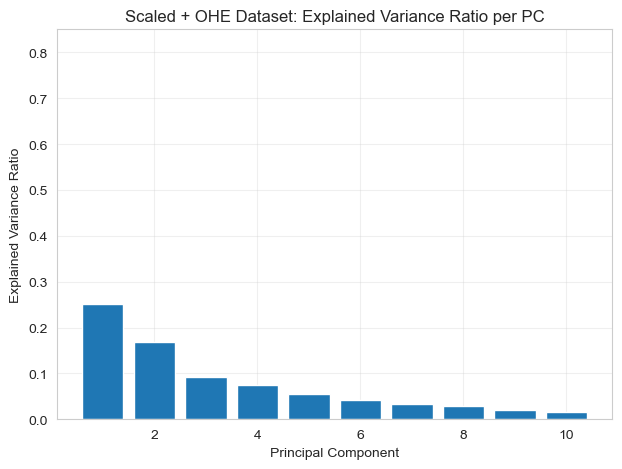

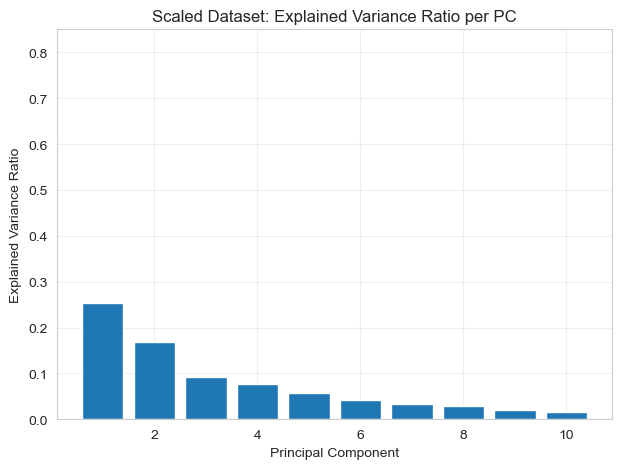

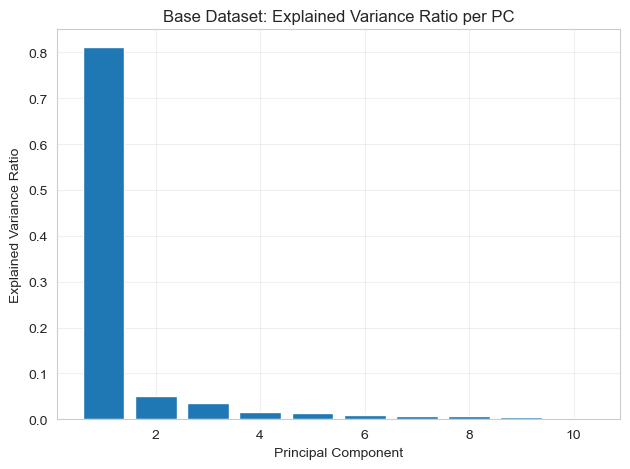

Figure 3:



In [28]:
# Display the variance explained ratio for each of the three datasets on the same scale to highlight the outsized impact of PC1 for the base dataset

num_components = 10

titles = ['Scaled + OHE', 'Scaled', 'Base']

# Trying to plot in a 3x1 subplot made the code functional but barely comprehensible: stacking 3 charts is more feasible
for i, v in enumerate(variance_explained):
    # Visualise explained variance ratios
    plt.bar(range(1, num_components + 1), v[:num_components], align="center")
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.title(f'{titles[i]} Dataset: Explained Variance Ratio per PC')
    plt.tight_layout()
    plt.ylim(0, .85) # display them on the same scales to highlight the outsized impact of PC1 for the base dataset
    plt.show()
print('Figure 3:\n')

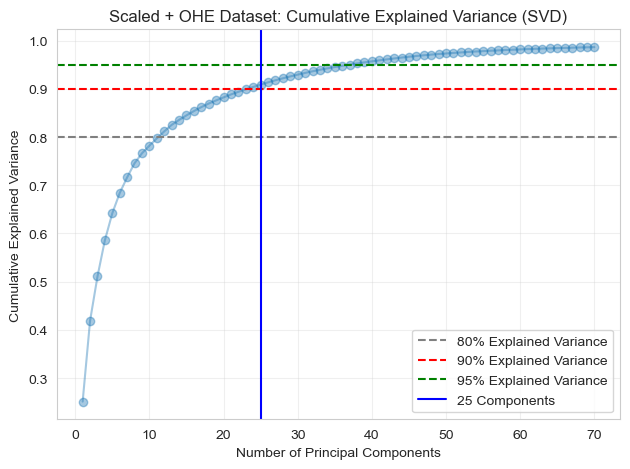

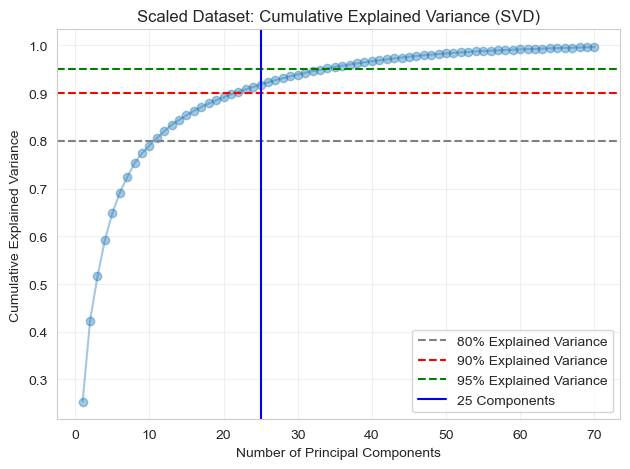

Figure 4:



In [ ]:
# Calculate the cumulative explained variance for the two remaining datasets: scaled and scaled with one hot encoding

cum_exp_var_with_ohe = np.cumsum(X_scaled_and_ohe_variance)
cum_exp_var_without_ohe = np.cumsum(X_scaled_variance)
cum_exp_var_list = [cum_exp_var_with_ohe, cum_exp_var_without_ohe]

components_displayed = 70 

# Plot an elbow plot for both with visual thresholds for 80%, 90% and 95% explained variance
titles = ['Scaled + OHE', 'Scaled']
for i, data in enumerate(cum_exp_var_list):
    plt.plot(range(1, components_displayed + 1), data[:components_displayed], marker='o', alpha=0.4)
    plt.axhline(y=0.8, color='grey', linestyle='--', label='80% Explained Variance')
    plt.axhline(y=0.9, color='red', linestyle='--', label='90% Explained Variance')
    plt.axhline(y=0.95, color='green', linestyle='--', label='95% Explained Variance')
    plt.axvline(x=25, color='blue', linestyle='-', label='25 Components')
    plt.title(f"{titles[i]} Dataset: Cumulative Explained Variance (SVD)")
    plt.ylabel("Cumulative Explained Variance")
    plt.xlabel("Number of Principal Components")
    plt.tight_layout()
    plt.legend();
print('Figure 4:\n')


In [30]:
# Select the final datasets for analysis

X_scaled_and_ohe_svd_25 = reduce_dimensions(df=X_scaled_and_ohe, components=25)
X_scaled_and_ohe_svd_50 = reduce_dimensions(df=X_scaled_and_ohe, components=50)
X_scaled_svd_25 = reduce_dimensions(df=X_scaled, components=25)
X_scaled_svd_50 = reduce_dimensions(df=X_scaled, components=50)

In [31]:
# Calculate the principal components loadings, align them to the original data labels and review 

def calculate_loadings(data=X_scaled, principal_component = 0):

    U, s, Vh = np.linalg.svd(data)

    # Get loadings for PC (row of Vh)
    pc_loadings = Vh[principal_component, :]
    # Convert to a series, add labels, sort and get the top 5
    loadings_series = pd.Series(pc_loadings, index=numeric_features)
    sorted_loadings = loadings_series.abs().sort_values(ascending=False)
    top_5_features = sorted_loadings.head(5)

    print(f"Top 5 loadings for PC{principal_component + 1}:")
    print(f'{loadings_series.loc[top_5_features.index]}\n')

print('Table 17:\n')
for i in range(0,3):
    calculate_loadings(principal_component = i)

Table 17:

Top 5 loadings for PC1:
medFamInc         0.183695
medIncome         0.182402
PctKids2Par       0.174552
pctWInvInc        0.174457
PctPopUnderPov   -0.173505
dtype: float64

Top 5 loadings for PC2:
PctRecImmig10     0.220035
PctRecImmig8      0.219931
PctRecImmig5      0.217840
PctRecentImmig    0.215290
PctForeignBorn    0.213180
dtype: float64

Top 5 loadings for PC3:
PersPerOccupHous      0.255396
PersPerFam            0.232648
PersPerOwnOccHous     0.225126
householdsize         0.221565
PersPerRentOccHous    0.201864
dtype: float64



Figure 5:



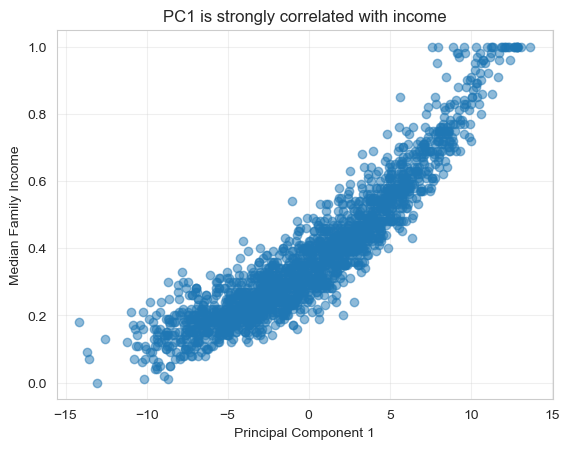

In [32]:
# PC1 and Income
plt.scatter(X_scaled_svd_25[:, 0], X_final['medFamInc'], alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Median Family Income')
plt.title('PC1 is strongly correlated with income');
print('Figure 5:\n')

Figure 6:



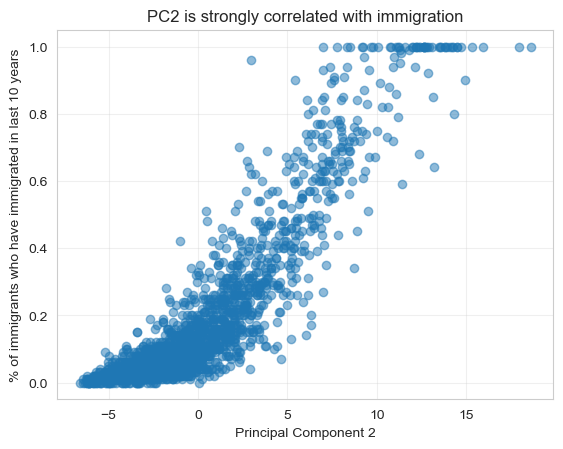

In [33]:
# PC2 and Immigration
plt.scatter(X_scaled_svd_25[:, 1], X_final['PctRecImmig10'], alpha=0.5)
plt.xlabel('Principal Component 2')
plt.ylabel('% of immigrants who have immigrated in last 10 years')
plt.title('PC2 is strongly correlated with immigration');
print('Figure 6:\n')

Figure 7:



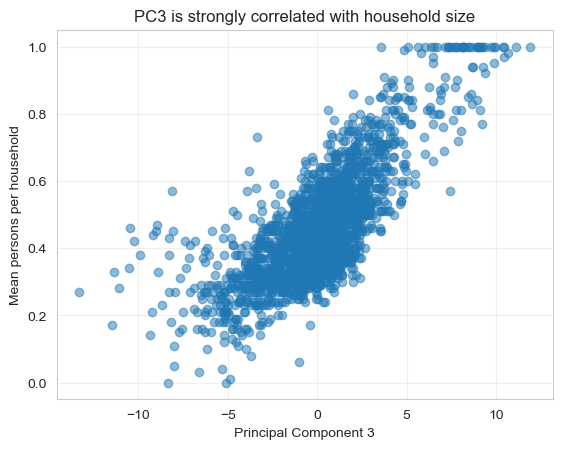

In [34]:
# PC3 and Household Size
plt.scatter(X_scaled_svd_25[:, 2], X_final['PersPerOccupHous'], alpha=0.5)
plt.xlabel('Principal Component 3')
plt.ylabel('Mean persons per household')
plt.title('PC3 is strongly correlated with household size');
print('Figure 7:\n')

Figure 8:



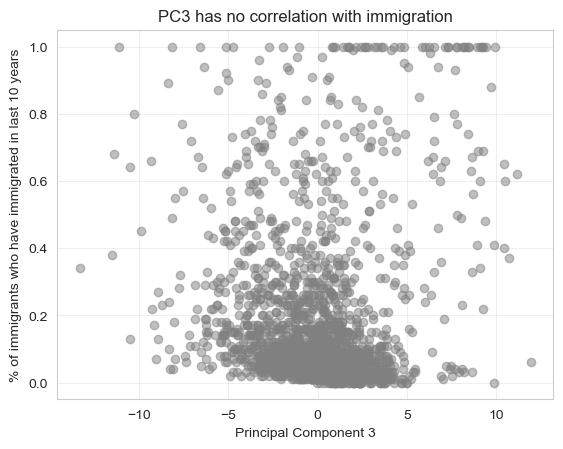

In [35]:
# Counter-example: no relation between PC3 and immigration demonstrates that principal components are representing distinct, independent features
plt.scatter(X_scaled_svd_25[:, 2], X_final['PctRecImmig10'], alpha=0.5, c='grey')
plt.xlabel('Principal Component 3')
plt.ylabel('% of immigrants who have immigrated in last 10 years')
plt.title('PC3 has no correlation with immigration');
print('Figure 8:\n')

## Linear Regression Results

A linear regression model was fit for each of the two datasets and the two sets of principal components. They were compared against the original data on RMSE.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

final_datasets = [X_scaled_and_ohe_svd_25, X_scaled_and_ohe_svd_50, X_scaled_svd_25, X_scaled_svd_50]

def linear_regression_pipeline(data):
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(data, y, test_size=0.2, random_state=40466218) # random_state = my student ID

    # Train a Decision Tree classifier on original data
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    rmse = root_mean_squared_error(y_test, y_pred)

    return rmse

# Compute RMSE for each dataset
rmse_results = {
    "Original Data": linear_regression_pipeline(X_final.drop(columns=['communityname'])),  # excludes columns with missing data and categorical variable
    "Scaled + OHE, 25 PCs": linear_regression_pipeline(X_scaled_and_ohe_svd_25),
    "Scaled + OHE, 50 PCs": linear_regression_pipeline(X_scaled_and_ohe_svd_50),
    "Scaled, 25 PCs": linear_regression_pipeline(X_scaled_svd_25),
    "Scaled, 50 PCs": linear_regression_pipeline(X_scaled_svd_50),
}

print('Table 18:\n')
# Convert to a DataFrame and display
rmse_results_df = pd.DataFrame((rmse_results.items()), columns=["Dataset", "RMSE"])
rmse_results_df


Table 18:



,Dataset,RMSE
0,Original Data,0.136900
1,"Scaled + OHE, 25 PCs",0.141137
2,"Scaled + OHE, 50 PCs",0.139625
3,"Scaled, 25 PCs",0.141138
4,"Scaled, 50 PCs",0.139627


In [37]:
# Display data shapes for final reference to dataset dimensionality
print(f"Original Data Shape: {X_final.drop(columns=['communityname']).shape}")
print(f"50 Principal Components: {X_scaled_and_ohe_svd_50.shape}")
print(f"25 Principal Components: {X_scaled_and_ohe_svd_25.shape}")

Original Data Shape: (1994, 99)
50 Principal Components: (1994, 50)
25 Principal Components: (1994, 25)


In conclusion, applying dimensionality reduction weakened the predictive performance of the model: a simple linear regression model on the original data performed best. For this dataset it improves model efficiency by reducing the size of the data significantly, but it does not improve model performance by reducing noise. 

This is a typical outcome and it requires a judgment call about whether there is a need for a more efficient model (reduced costs, faster inference). If so, PCA using SVD effectively retains a significant amount of the signal in the data while making it more efficient.

The inclusion of the one hot encoded categorical variable made a negligible impact while substantially increasing the dataset size: it requires no judgement call, it should be excluded from analysis as per the data authors' recommendation.

## Appendices

### Appendix A

In [38]:
# Describes where the data comes from
dataset_abstract = metadata['abstract']
print(f'Abstract: {dataset_abstract}\n')

# Describes what the data contains, how it was normalised and any limitations
dataset_description = metadata['additional_info']['summary']
print(f'Description:\n {dataset_description}')

Abstract: Communities within the United States. The data combines socio-economic data from the 1990 US Census, law enforcement data from the 1990 US LEMAS survey, and crime data from the 1995 FBI UCR.

Description:
   Many variables are included so that algorithms that select or learn weights for attributes could be tested. However, clearly unrelated attributes were not included; attributes were picked if there was any plausible connection to crime (N=122), plus the attribute to be predicted (Per Capita Violent Crimes). The variables included in the dataset involve the community, such as the percent of the population considered urban, and the median family income, and involving law enforcement, such as per capita number of police officers, and percent of officers assigned to drug units. 
 
 The per capita violent crimes variable was calculated using population and the sum of crime variables considered violent crimes in the United States: murder, rape, robbery, and assault. There was ap

### Appendix B

In [39]:
# Almost all of the variables with extensive missing values were from the 1990 US LEMAS survey
# View the full set of variables from this survey
print('Table 19:\n')
variables_descriptions_enhanced[variables_descriptions_enhanced['source'] == '1990 US LEMAS']

Table 19:



,variable,type,missing_values,info,source,topic
101,LemasSwornFT,Continuous,yes,number of sworn full time police officers (nu...,1990 US LEMAS,Police
102,LemasSwFTPerPop,Integer,yes,sworn full time police officers per 100K popu...,1990 US LEMAS,Police
103,LemasSwFTFieldOps,Continuous,yes,number of sworn full time police officers in ...,1990 US LEMAS,Police
104,LemasSwFTFieldPerPop,Continuous,yes,sworn full time police officers in field oper...,1990 US LEMAS,Police
105,LemasTotalReq,Continuous,yes,total requests for police (numeric - decimal),1990 US LEMAS,Police
106,LemasTotReqPerPop,Continuous,yes,total requests for police per 100K popuation ...,1990 US LEMAS,Police
107,PolicReqPerOffic,Continuous,yes,total requests for police per police officer ...,1990 US LEMAS,Police
108,PolicPerPop,Integer,yes,police officers per 100K population (numeric ...,1990 US LEMAS,Police
109,RacialMatchCommPol,Continuous,yes,a measure of the racial match between the com...,1990 US LEMAS,Police
110,PctPolicWhite,Continuous,yes,percent of police that are caucasian (numeric...,1990 US LEMAS,Police


### Appendix C

In [40]:
# Illustrate that scikit-learn's StandardScaler replicates the manual calculation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_pop = scaler.fit_transform(householdsize_df[['householdsize', 'standardised']])
print('Table 20:\n')
pd.DataFrame(scaled_pop, columns = ['householdsize', 'standardised'])

Table 20:



,householdsize,standardised
0,-0.814997,-0.814997
1,-1.853636,-1.853636
2,-0.265129,-0.265129
3,1.873246,1.873246
4,0.529125,0.529125
...,...,...
1989,-0.387322,-0.387322
1990,3.034078,3.034078
1991,-0.570611,-0.570611
1992,0.284739,0.284739



### Notes on AI Use

AI was used on two supporting pieces of the notebook:

- Parsing the variable descriptions from the metadata (see comment '# Parse variable descriptions into a DataFrame') and categorising them - tidying up a messy conditional loop with parsing at multiple levels
- Calculating the principal component loadings to identify correlations with the original features (see comment '# Calculate the principal components loadings, align them to the original data labels and review') 

These were designed to semantically enhance and contextualise the dataset and interpretation, but did not play a significant role in the core data preparation, dimensionality reduction, analysis or model development phases. The majority of the code is boilerplate pandas, seaborn and matplotlib, and iterations of what we have practiced in class, so there was little need / opportunity for AI-assisted code generation.